
     Predicting the price of cars



In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv('/kaggle/input/d/anzir_rahman_khan/used-car-price-prediction-dataset/train.csv')

df['horsepower'] = df['engine'].apply(lambda x:x[0:x.index('HP') if 'HP' in x else 0])
df['horsepower']=df['horsepower'].replace('',306.9)
df['litre-capacity'] = df['engine'].apply(lambda x:x[0:x.index('L ') if 'L ' in x else 0])
df['litre-capacity'] = df['litre-capacity'].apply(lambda x:x[x.index(' ') if ' ' in x else 0:len(x)])
df['litre-capacity']=df['litre-capacity'].replace('',3.67)


df['horsepower']= df['horsepower'].astype(float)
df['litre-capacity']= df['litre-capacity'].astype(float)


def Perform_log_transform(df,col_log):
    """#Perform Log Transformation of dataframe , and list of columns """
    for colname in col_log:
        df[colname + '_log'] = np.log(df[colname])
    #df.drop(col_log, axis=1, inplace=True)
    df.info()

Perform_log_transform(df,['model_year','milage','horsepower','litre-capacity'])
#'price'

# Prepare df_submission for predictions the exact same way as the training data

df_submission = pd.read_csv('/kaggle/input/d/anzir_rahman_khan/used-car-price-prediction-dataset/test.csv')

df_submission['horsepower'] = df_submission['engine'].apply(lambda x:x[0:x.index('HP') if 'HP' in x else 0])
df_submission['horsepower']=df_submission['horsepower'].replace('',306.9)
df_submission['litre-capacity'] = df_submission['engine'].apply(lambda x:x[0:x.index('L ') if 'L ' in x else 0])
df_submission['litre-capacity'] = df_submission['litre-capacity'].apply(lambda x:x[x.index(' ') if ' ' in x else 0:len(x)])
df_submission['litre-capacity']=df_submission['litre-capacity'].replace('',3.67)


df_submission['horsepower']= df_submission['horsepower'].astype(float)
df_submission['litre-capacity']= df_submission['litre-capacity'].astype(float)


Perform_log_transform(df_submission,['model_year','milage','horsepower','litre-capacity'])





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54273 entries, 0 to 54272
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  54273 non-null  int64  
 1   brand               54273 non-null  object 
 2   model               54273 non-null  object 
 3   model_year          54273 non-null  int64  
 4   milage              54273 non-null  int64  
 5   fuel_type           54273 non-null  object 
 6   engine              54273 non-null  object 
 7   transmission        54273 non-null  object 
 8   ext_col             54273 non-null  object 
 9   int_col             54273 non-null  object 
 10  accident            54273 non-null  object 
 11  clean_title         54273 non-null  object 
 12  price               54273 non-null  int64  
 13  horsepower          54273 non-null  float64
 14  litre-capacity      54273 non-null  float64
 15  model_year_log      54273 non-null  float64
 16  mila

Data Checks

  

In [9]:
#Missing value
df.isnull().sum()

id                    0
brand                 0
model                 0
model_year            0
milage                0
fuel_type             0
engine                0
transmission          0
ext_col               0
int_col               0
accident              0
clean_title           0
price                 0
horsepower            0
litre-capacity        0
model_year_log        0
milage_log            0
horsepower_log        0
litre-capacity_log    0
dtype: int64

In [10]:
#Duplication
df.duplicated().sum()

0

In [11]:
#datatype
df.dtypes


id                      int64
brand                  object
model                  object
model_year              int64
milage                  int64
fuel_type              object
engine                 object
transmission           object
ext_col                object
int_col                object
accident               object
clean_title            object
price                   int64
horsepower            float64
litre-capacity        float64
model_year_log        float64
milage_log            float64
horsepower_log        float64
litre-capacity_log    float64
dtype: object

In [12]:
#unique values
df.nunique()

id                    54273
brand                    53
model                  1827
model_year               34
milage                 3212
fuel_type                 7
engine                 1061
transmission             46
ext_col                 260
int_col                 124
accident                  2
clean_title               1
price                  1481
horsepower              342
litre-capacity           61
model_year_log           34
milage_log             3212
horsepower_log          342
litre-capacity_log       61
dtype: int64

In [13]:

df.describe()

,id,model_year,milage,price,horsepower,litre-capacity,model_year_log,milage_log,horsepower_log,litre-capacity_log
count,54273.000000,54273.000000,54273.000000,5.427300e+04,54273.000000,54273.000000,54273.000000,54273.000000,54273.000000,54273.000000
mean,27136.000000,2015.091979,72746.175667,3.921844e+04,329.844606,3.716481,7.608416,10.827759,5.748535,1.247833
std,15667.409917,5.588909,50469.490448,7.282634e+04,104.140658,1.328694,0.002777,1.062492,0.321111,0.365001
min,0.000000,1974.000000,100.000000,2.000000e+03,76.000000,0.650000,7.587817,4.605170,4.330733,-0.430783
25%,13568.000000,2012.000000,32268.000000,1.550000e+04,261.000000,3.000000,7.606885,10.381831,5.564520,1.098612
50%,27136.000000,2016.000000,66107.000000,2.800000e+04,306.900000,3.500000,7.608871,11.099030,5.726522,1.252763
75%,40704.000000,2019.000000,102000.000000,4.500000e+04,395.000000,4.600000,7.610358,11.532728,5.978886,1.526056
max,54272.000000,2024.000000,405000.000000,2.954083e+06,1020.000000,8.400000,7.612831,12.911642,6.927558,2.128232


More Stats

In [14]:
categorical_columns = ['brand','model','fuel_type','engine','transmission','ext_col','int_col','accident','clean_title']

for col in categorical_columns:
    
    print(f"Category in {col} is : {df[col].unique()}")

Category in brand is : ['Ford' 'BMW' 'Jaguar' 'Pontiac' 'Acura' 'Audi' 'GMC' 'Maserati'
 'Chevrolet' 'Porsche' 'Mercedes-Benz' 'Tesla' 'Lexus' 'Kia' 'Lincoln'
 'Dodge' 'Volkswagen' 'Land' 'Cadillac' 'Mazda' 'RAM' 'Subaru' 'Hyundai'
 'MINI' 'Jeep' 'Honda' 'Hummer' 'Nissan' 'Toyota' 'Volvo' 'Genesis'
 'Mitsubishi' 'Buick' 'INFINITI' 'McLaren' 'Scion' 'Lamborghini' 'Bentley'
 'Suzuki' 'Ferrari' 'Alfa' 'Rolls-Royce' 'Chrysler' 'Aston' 'Rivian'
 'Lotus' 'Saturn' 'Lucid' 'Mercury' 'Maybach' 'FIAT' 'Plymouth' 'Bugatti']
Category in model is : ['F-150 Lariat' '335 i' 'XF Luxury' ... 'Q4 e-tron Sportback Premium'
 'Countryman Cooper' 'S-10 LS']
Category in fuel_type is : ['Gasoline' 'Hybrid' 'E85 Flex Fuel' 'Diesel' '–' 'Plug-In Hybrid'
 'not supported']
Category in engine is : ['375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel'
 '300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel'
 '300.0HP 4.2L 8 Cylinder Engine Gasoline Fuel' ... '3.0L'
 '3.0 Liter GTDI' '120.0HP 2.2L 4 Cylinder Engine Flex 

Data analysis

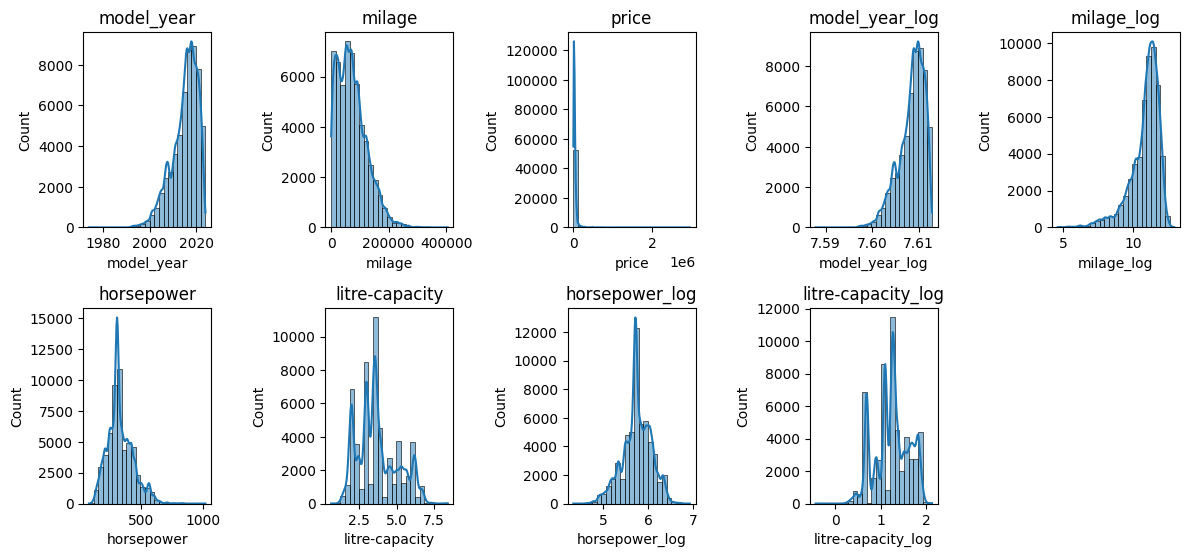

In [15]:
# Distribution of Numerical Features
numerical_features = ['model_year','milage','price','model_year_log','milage_log','horsepower','litre-capacity','horsepower_log','litre-capacity_log']
#'price_log'
plt.figure(figsize=(12, 8))
for feature in numerical_features:
    plt.subplot(3, 5, numerical_features.index(feature) + 1)
    sns.histplot(data=df[feature], bins=25, kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

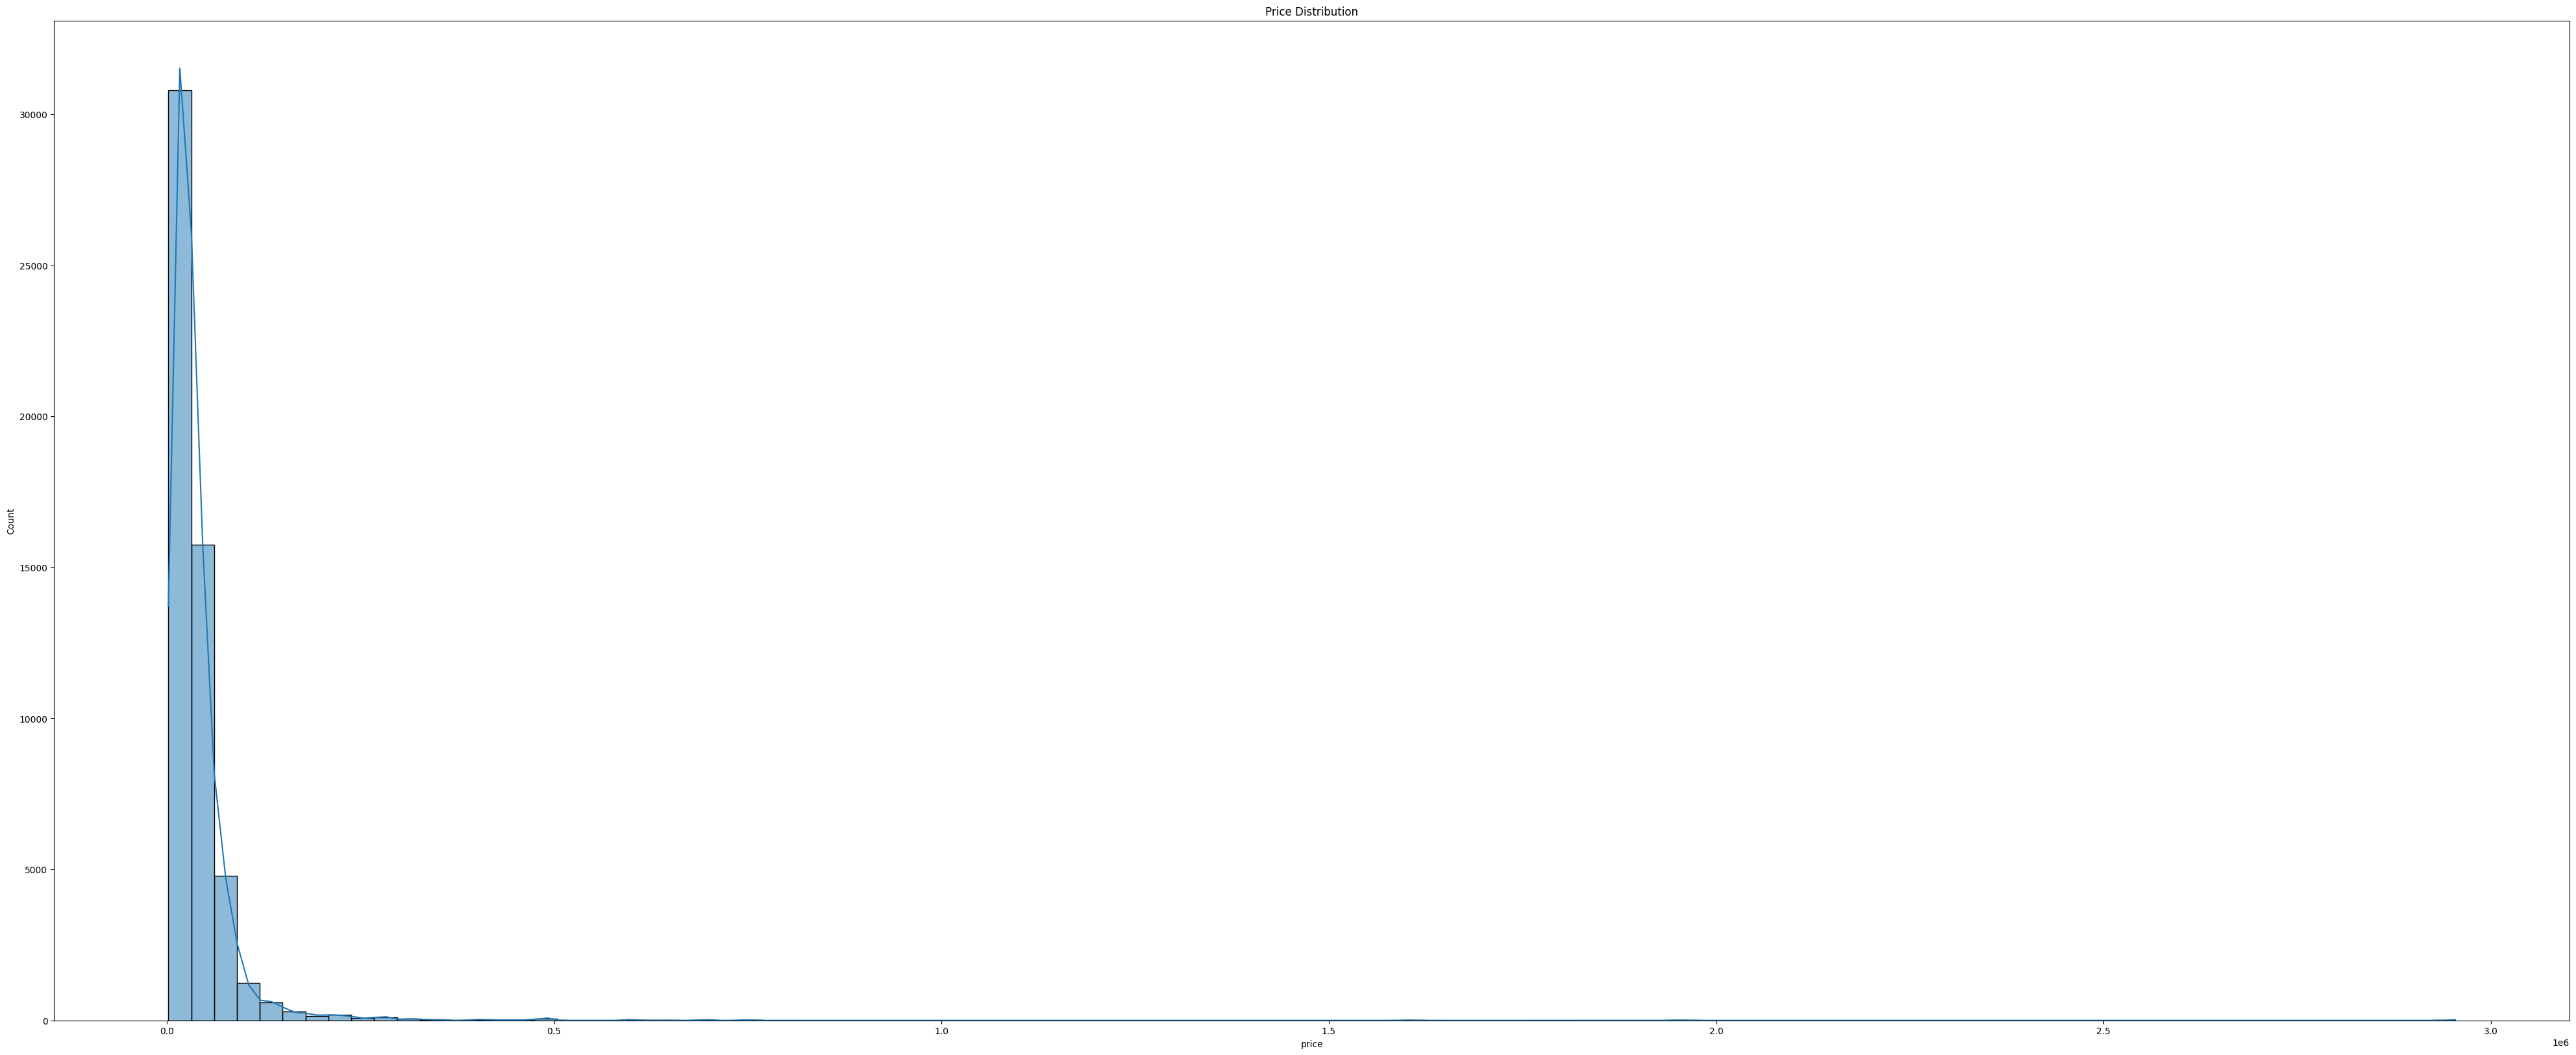

In [16]:
# Price
plt.figure(figsize=(50, 20))
sns.histplot(data=df['price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.show()

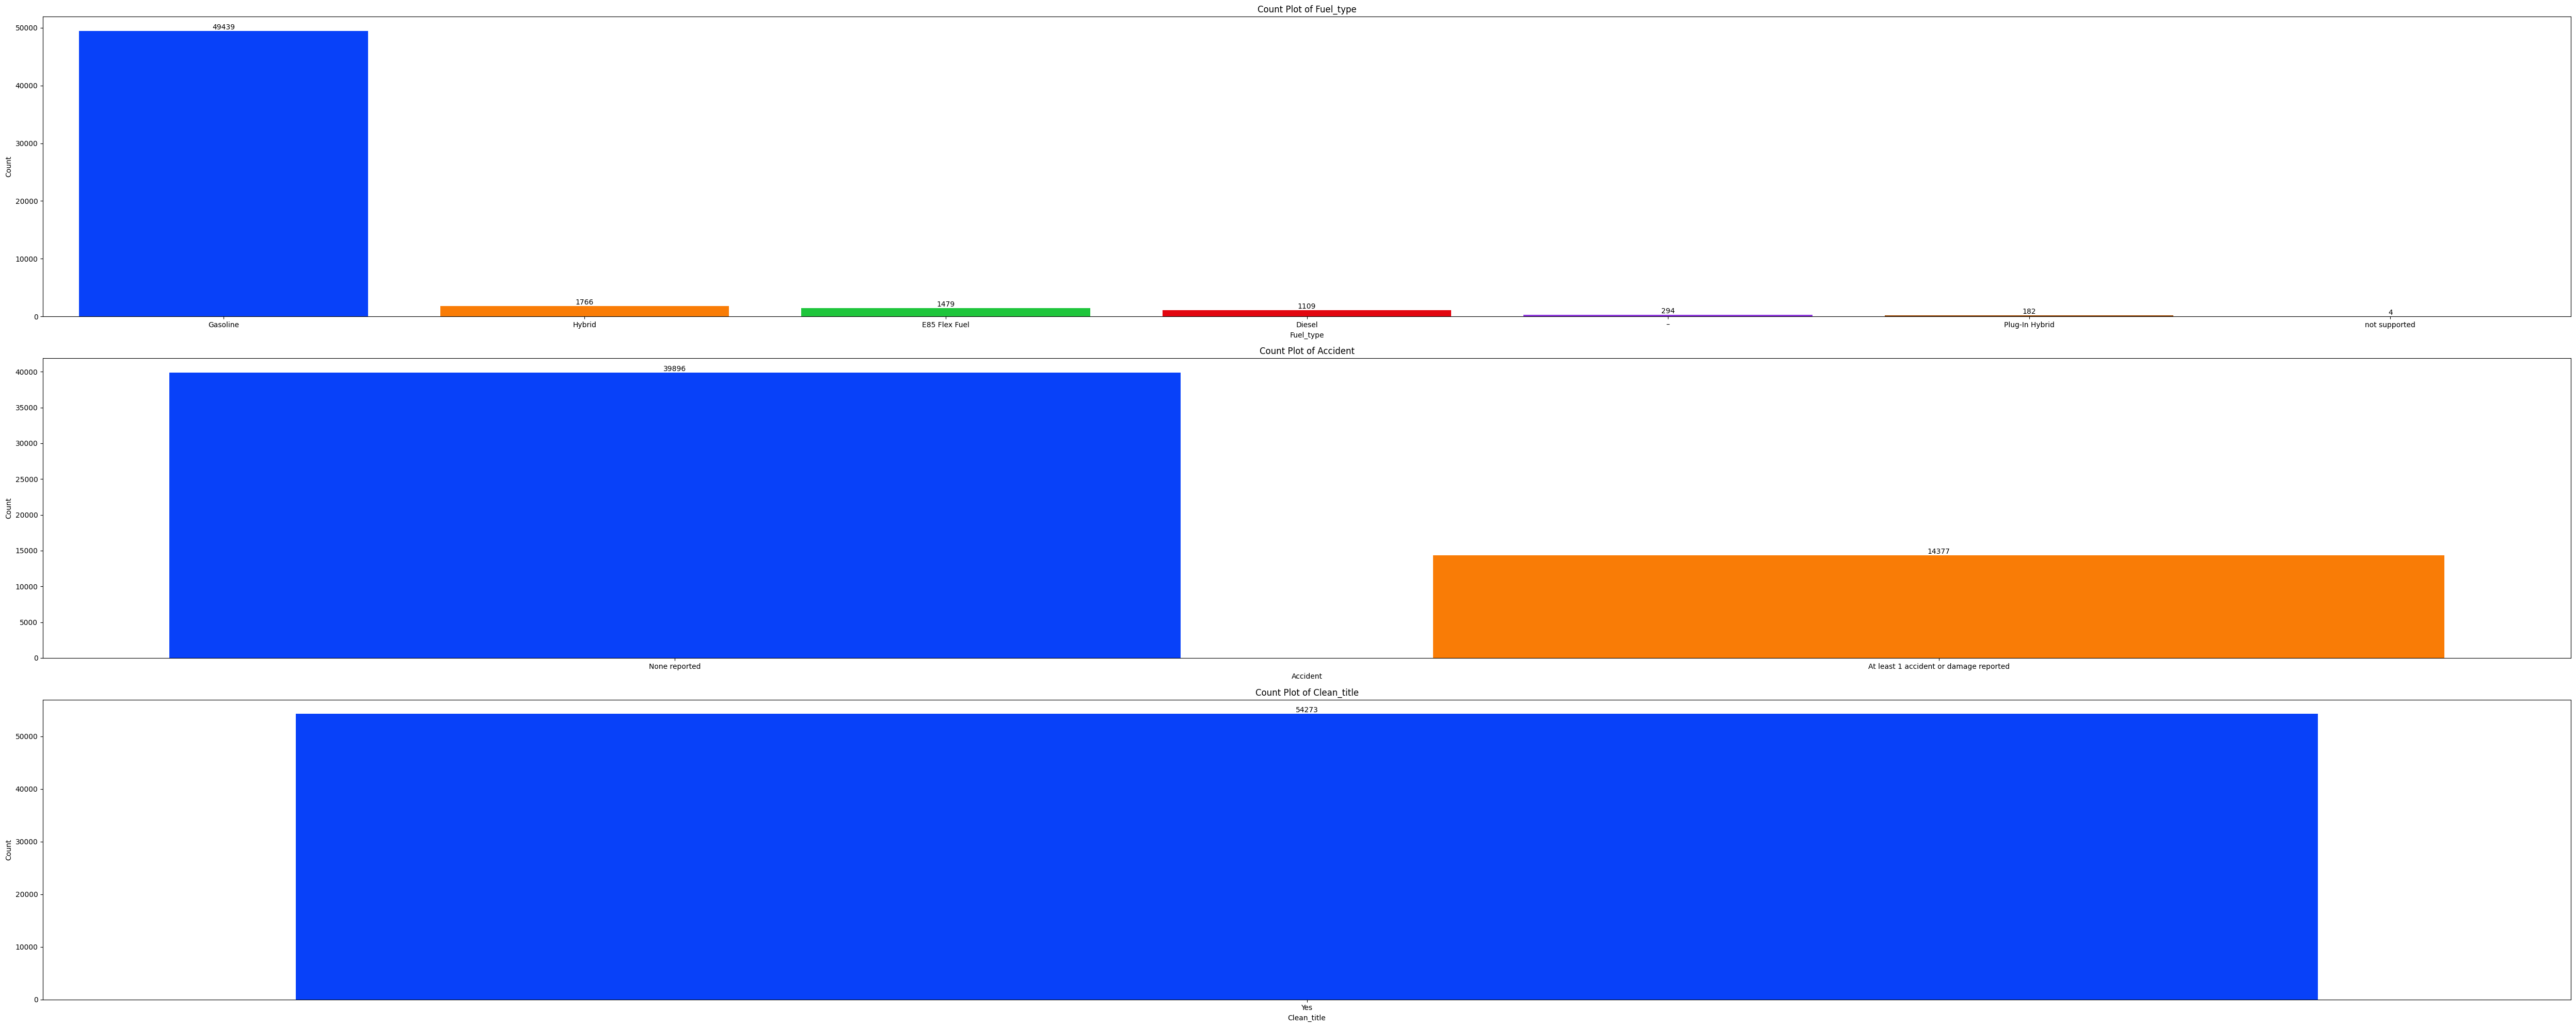

In [17]:

categorical_columns = ['fuel_type','accident','clean_title']
#'fuel_type','accident','clean_title','engine','transmission','ext_col','int_col','accident','clean_title']


#subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(50, 20))
axes = axes.ravel()  # Flatten the 2D array of axes

# Loop through each categorical column
for i, column in enumerate(categorical_columns):
    sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=10)
    axes[i].set_title(f'Count Plot of {column.capitalize()}')
    axes[i].set_xlabel(column.capitalize())
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.show()




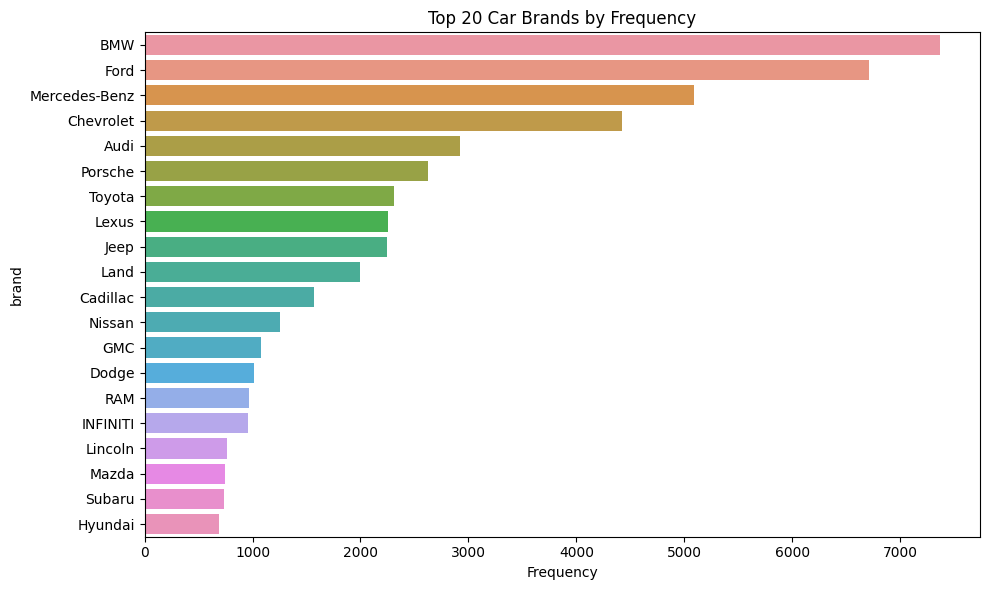

In [18]:
n = 20 
top_car_models = df['brand'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Brands by Frequency')
plt.xlabel('Frequency')
plt.ylabel('brand')
plt.tight_layout()
plt.show()

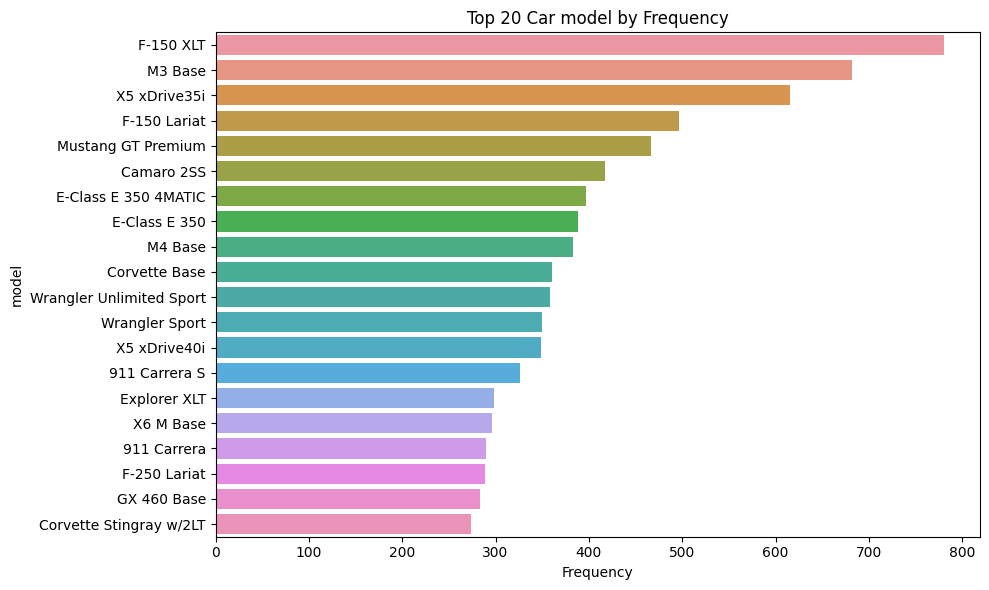

In [19]:
n = 20  
top_car_models = df['model'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car model by Frequency')
plt.xlabel('Frequency')
plt.ylabel('model')
plt.tight_layout()
plt.show()

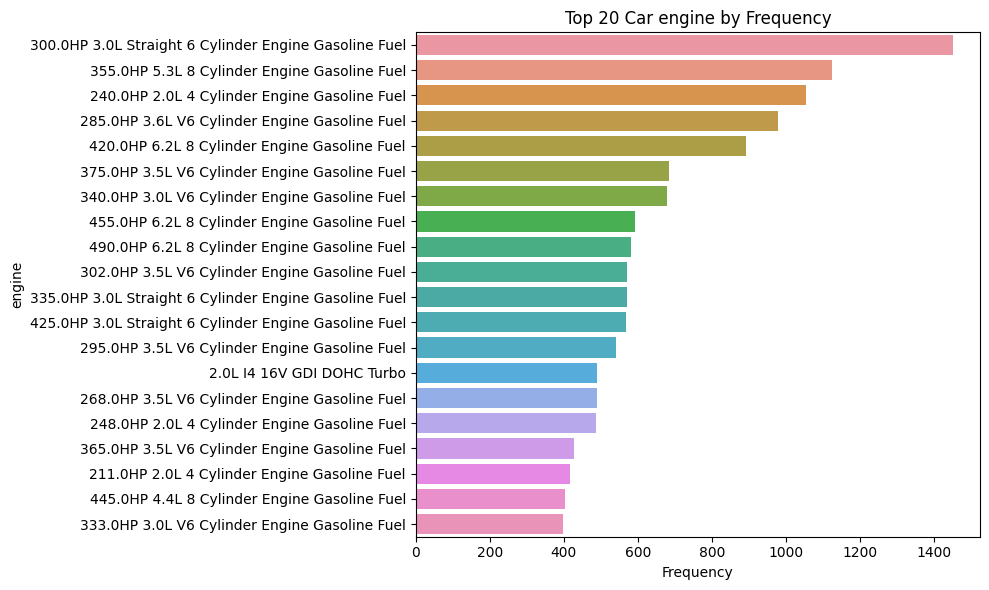

In [20]:
n = 20
top_car_models = df['engine'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car engine by Frequency')
plt.xlabel('Frequency')
plt.ylabel('engine')
plt.tight_layout()
plt.show()

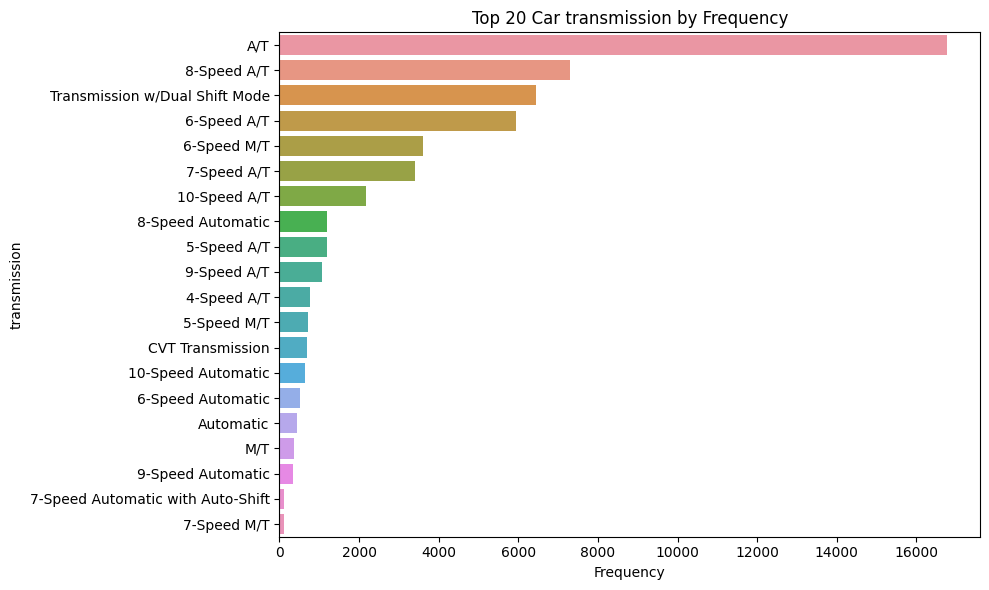

In [21]:
n = 20
top_car_models = df['transmission'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car transmission by Frequency')
plt.xlabel('Frequency')
plt.ylabel('transmission')
plt.tight_layout()
plt.show()

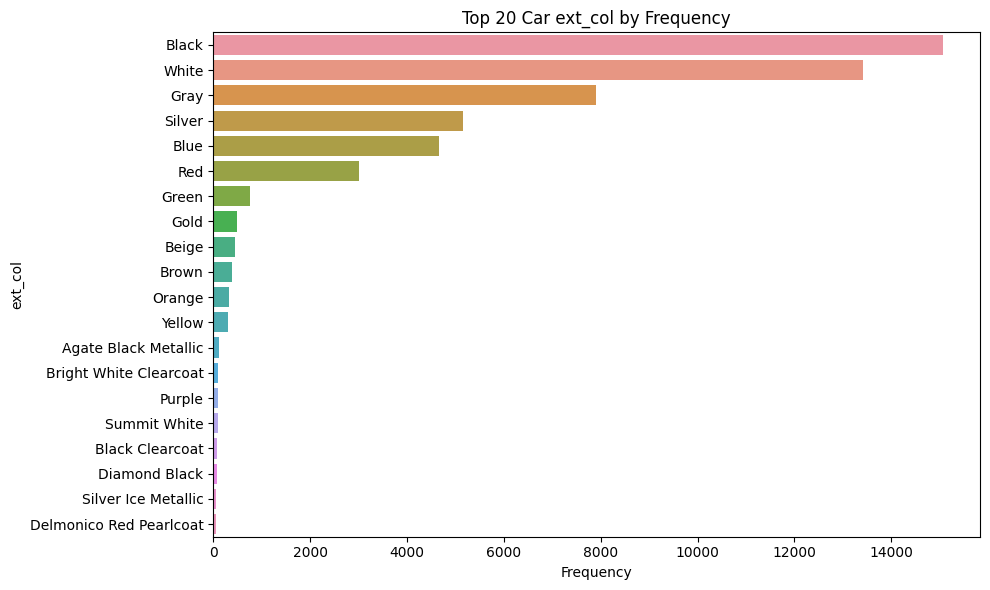

In [22]:
n = 20
top_car_models = df['ext_col'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car ext_col by Frequency')
plt.xlabel('Frequency')
plt.ylabel('ext_col')
plt.tight_layout()
plt.show()

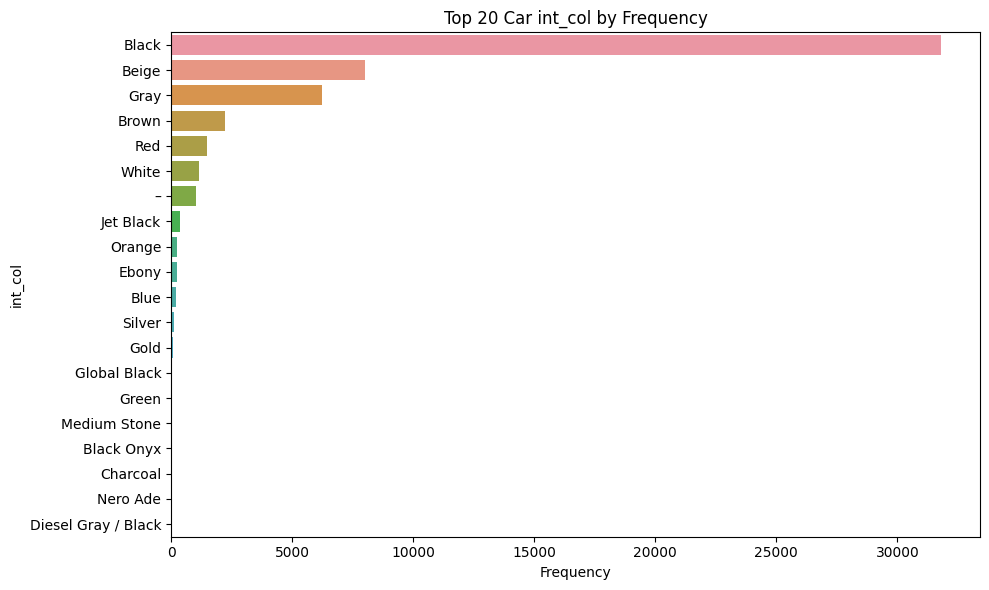

In [23]:
n = 20 
top_car_models = df['int_col'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car int_col by Frequency')
plt.xlabel('Frequency')
plt.ylabel('int_col')
plt.tight_layout()
plt.show()

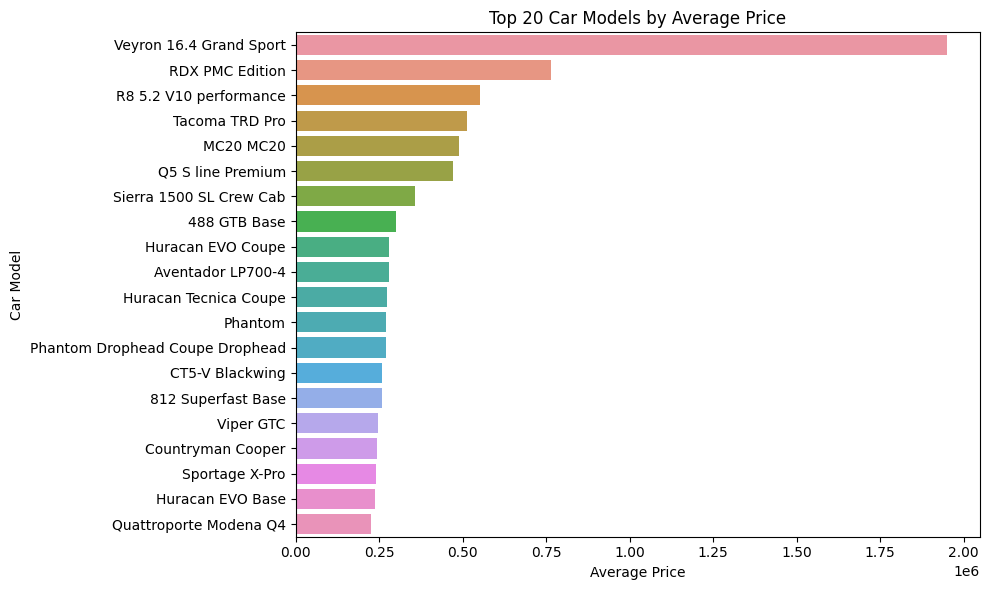

In [24]:

avg_prices_by_car = df.groupby('model')['price'].mean().sort_values(ascending=False)

n = 20
top_car_models = avg_prices_by_car.head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
#plt.ticklabel_format(style='plain')
plt.title(f'Top {n} Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

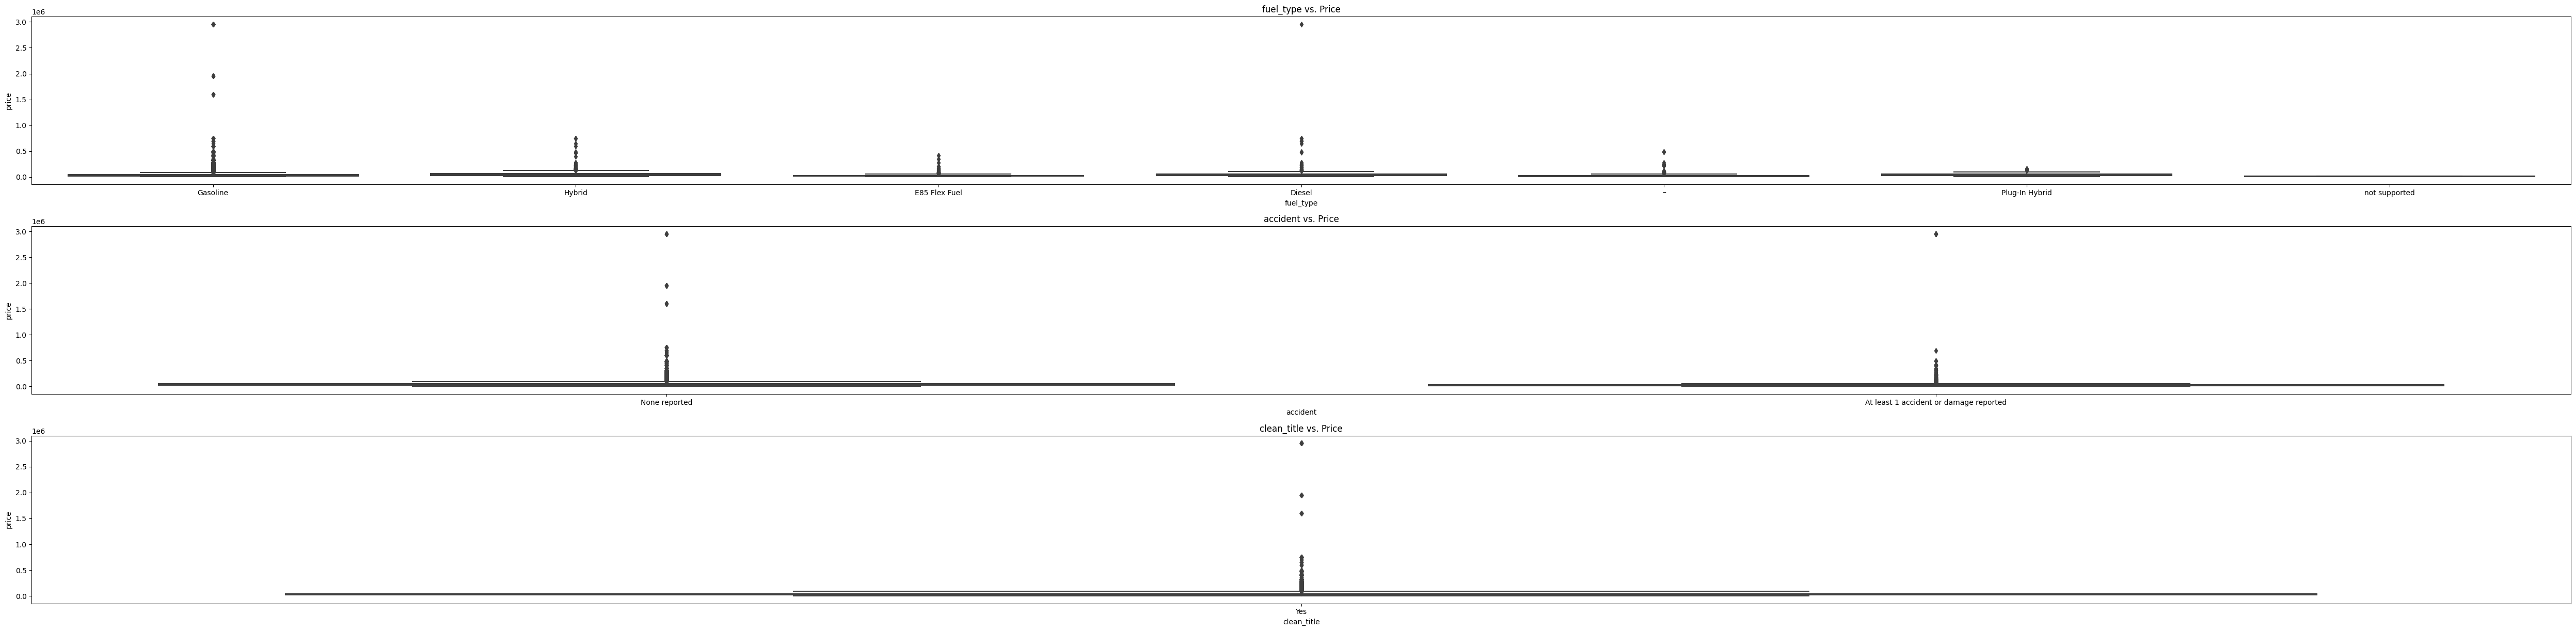

In [25]:
# CategoricalFeature vs. Price
plt.figure(figsize=(50,20))
for feature in categorical_columns:
    plt.subplot(5, 1,categorical_columns.index(feature) + 1)
    sns.boxplot(data=df, x=feature, y='price')
    plt.title(f'{feature} vs. Price')
plt.tight_layout()
plt.show()

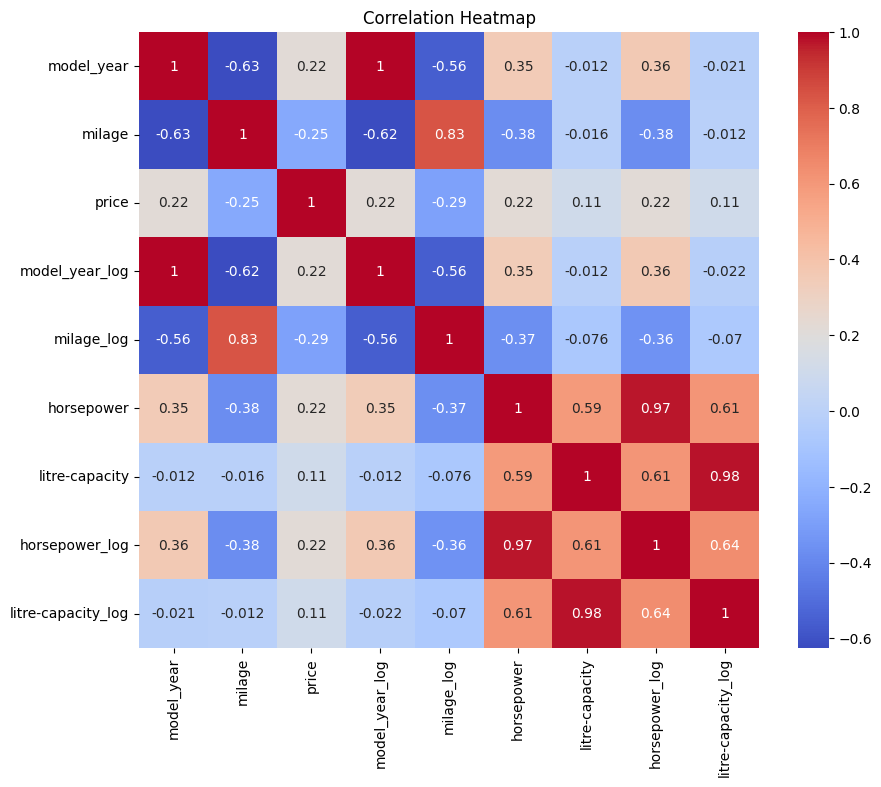

In [26]:
# Correlations
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Encoding and Scaling



In [27]:

# Define categorical and numerical columns
categorical_columns = ['brand','model','fuel_type','accident','clean_title','engine','transmission','ext_col','int_col','accident']
numerical_columns = ['model_year','milage','model_year_log','milage_log','horsepower','litre-capacity','horsepower_log','litre-capacity_log']
#numerical_columns = ['model_year','milage']
#,'horsepower','litre-capacity']

# Encoding categorical variables
label_encoder = LabelEncoder()
#df['price'] = df['price']/100000
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

    mean = df[column].mean(axis=0)
    df[column] -= mean
    std = df[column].std(axis=0)
    df[column] /= std
    print(column)
    print(mean , std)
    
    # Prepare df_submission for predictions the exact same way as the training data

    df_submission[column] = label_encoder.fit_transform(df_submission[column])

    df_submission[column] -= mean
    df_submission[column] /= std

# Feature scaling
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])


#correlation_matrix = df.corr()
#plt.figure(figsize=(50, 20))
#sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
#plt.title('Correlation Heatmap')
#plt.show()


# Prepare df_submission for predictions the exact same way as the training data
df_submission[numerical_columns] = scaler.fit_transform(df_submission[numerical_columns])

brand
20.9059937722256 14.796165898104585
model
890.4039024929523 541.8721802610039
fuel_type
1.9930167855102905 0.4921695463502306
accident
0.7350984835922098 0.441284818486628
clean_title
0.0 0.0
engine
565.5707994767196 262.41131602938475
transmission
26.69378880843145 11.319566811308782
ext_col
124.01590109262432 97.41124230149296
int_col
23.891382455364546 30.436187153137517
accident
0.7350984835922098 0.441284818486628


In [28]:
#sns.pairplot(df)

Train the LR Model 

In [29]:
# Splitting the dataset
X = df.drop(['id','price', 'clean_title'], axis=1)  # Include the engineered features 
#'transmission','model','brand','horsepower','horsepower','milage','model_year_log','litre-capacity','price_log'
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)


# Model training
LRmodel = LinearRegression()
LRmodel.fit(X_train, y_train)

# Predictions
y_pred = LRmodel.predict(X_test)

#model.score(X_test,y_test)

          brand     model  model_year    milage  fuel_type    engine  \
21234  1.966321 -1.497408    0.162470  1.788301   0.014189 -0.638581   
49993  1.966321  1.671236   -0.553240  1.606368   0.014189 -2.105743   
47016  0.344279  0.707909   -0.016458 -0.119998   0.014189 -0.352770   
28922 -0.466742 -0.499018    0.699252  0.247812   0.014189 -0.196527   
22726  0.952544 -1.047118   -0.553240  0.341870   0.014189 -1.305473   
...         ...       ...         ...       ...        ...       ...   
11284  2.101491  1.608490    0.520325 -0.239477   0.014189  0.131203   
44732 -0.804667 -0.716781   -0.016458 -0.877294   0.014189  1.377338   
38158  0.614619 -0.748154   -0.553240  0.658896   0.014189 -1.640824   
860    1.358055 -1.351617   -0.911095 -1.173912   0.014189  1.232528   
15795 -1.142593  1.562354    0.520325  0.005881   0.014189 -0.120310   

       transmission   ext_col   int_col  accident  horsepower  litre-capacity  \
21234     -1.651458  1.283056 -0.587833  0.600296   -0

In [30]:
# Evaluate the model
import math
mse = mean_squared_error(y_test, y_pred)
r2_square = r2_score(y_test,y_pred)
rmse = math.sqrt(mse)  
print(f'Root Mean Squared Error: {rmse}')
print(f" R-squared: {r2_square}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error: 48751.75172067153
 R-squared: 0.19117480528979647
Mean Squared Error: 2376733295.833999


In [31]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':(y_test-y_pred)})
pred_df

,Actual Value,Predicted Value,Difference
42508,64000,94567.548917,-30567.548917
43045,145000,116324.078909,28675.921091
34855,6995,12444.182134,-5449.182134
15207,24700,20239.724082,4460.275918
39125,6700,6397.014323,302.985677
...,...,...,...
34708,17500,34523.085267,-17023.085267
42401,47999,77485.376291,-29486.376291
50625,89000,115854.777496,-26854.777496
29071,34000,40509.484168,-6509.484168


In [32]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor


dt_regressor = DecisionTreeRegressor(random_state=0)
dt_regressor.fit(X_train,y_train)
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)
dt_regressor.score(X_test,y_test)

-3.276840041458521

In [33]:
pred2_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_test_pred ,'Difference':(y_test-y_test_pred) })
pred2_df

,Actual Value,Predicted Value,Difference
42508,64000,89999.0,-25999.0
43045,145000,145000.0,0.0
34855,6995,7999.0,-1004.0
15207,24700,18500.0,6200.0
39125,6700,10000.0,-3300.0
...,...,...,...
34708,17500,35999.0,-18499.0
42401,47999,67999.0,-20000.0
50625,89000,69900.0,19100.0
29071,34000,20995.0,13005.0


In [34]:
# Evaluate the model
mse = mean_squared_error(y_test, y_test_pred)
r2_square = r2_score(y_test,y_test_pred)
rmse = math.sqrt(mse)  
print(f'Root Mean Squared Error: {rmse}')
print(f" R-squared: {r2_square}")    # Prepare df_submission for predictions the exact same way as the training data

print(f'Mean Squared Error: {mse}')

Root Mean Squared Error: 112104.8478006447
 R-squared: -3.276840041458521
Mean Squared Error: 12567496900.405712


In [35]:
Rf = RandomForestRegressor(n_estimators = 15,
                              criterion = 'friedman_mse',
                              random_state = 20,
                              n_jobs = -1)
Rf.fit(X_train,y_train)
Rf_train_pred = Rf.predict(X_train)
Rf_test_pred = Rf.predict(X_test)






In [36]:
pred3_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':Rf_test_pred ,'Difference':(y_test-Rf_test_pred) })
pred3_df

,Actual Value,Predicted Value,Difference
42508,64000,68305.733333,-4305.733333
43045,145000,192805.666667,-47805.666667
34855,6995,14271.466667,-7276.466667
15207,24700,21299.466667,3400.533333
39125,6700,10303.333333,-3603.333333
...,...,...,...
34708,17500,24726.333333,-7226.333333
42401,47999,87689.933333,-39690.933333
50625,89000,74222.933333,14777.066667
29071,34000,15603.200000,18396.800000


In [37]:
mse = mean_squared_error(y_test,Rf_test_pred)
r2_square = r2_score(y_test,Rf_test_pred)
rmse = math.sqrt(mse)  
print(f'Root Mean Squared Error: {rmse}')
print(f" R-squared: {r2_square}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error: 58385.639187058914
 R-squared: -0.16007561743286658
Mean Squared Error: 3408882863.28143


K FOLD

In [38]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

train_data = X_train.values
train_targets = y_train.values
test_data=X_test.values
test_targets=y_test.values
#test_data = y_test.to_numpy
train_data.shape
train_targets.shape
print(X_train)
print(train_data)
print(y_train)
print(train_targets)



2024-06-23 20:52:16.718921: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-23 20:52:16.719062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-23 20:52:16.882421: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


          brand     model  model_year    milage  fuel_type    engine  \
21234  1.966321 -1.497408    0.162470  1.788301   0.014189 -0.638581   
49993  1.966321  1.671236   -0.553240  1.606368   0.014189 -2.105743   
47016  0.344279  0.707909   -0.016458 -0.119998   0.014189 -0.352770   
28922 -0.466742 -0.499018    0.699252  0.247812   0.014189 -0.196527   
22726  0.952544 -1.047118   -0.553240  0.341870   0.014189 -1.305473   
...         ...       ...         ...       ...        ...       ...   
11284  2.101491  1.608490    0.520325 -0.239477   0.014189  0.131203   
44732 -0.804667 -0.716781   -0.016458 -0.877294   0.014189  1.377338   
38158  0.614619 -0.748154   -0.553240  0.658896   0.014189 -1.640824   
860    1.358055 -1.351617   -0.911095 -1.173912   0.014189  1.232528   
15795 -1.142593  1.562354    0.520325  0.005881   0.014189 -0.120310   

       transmission   ext_col   int_col  accident  horsepower  litre-capacity  \
21234     -1.651458  1.283056 -0.587833  0.600296   -0

In [39]:

k = 4
num_val_samples = len(train_data) // k
num_epochs = 38
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)




Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


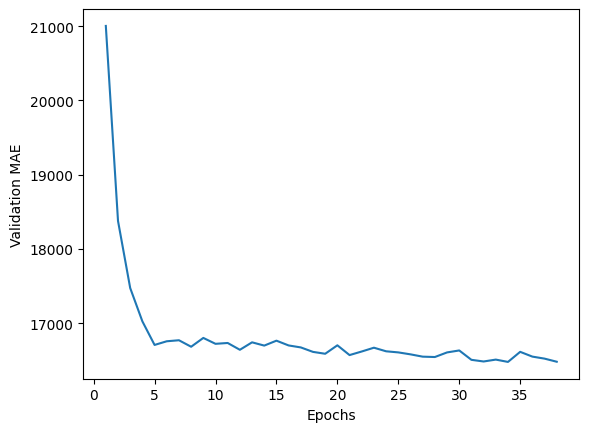

In [40]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

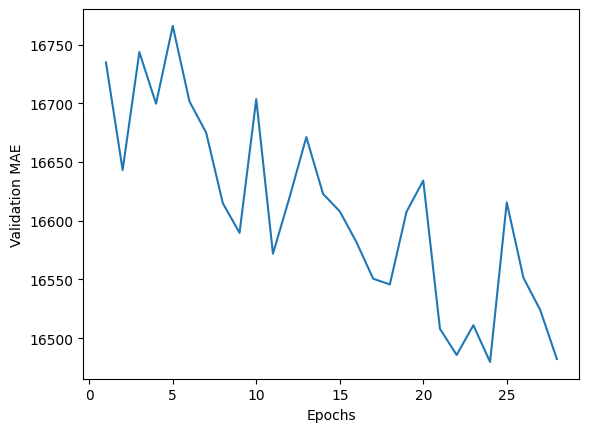

In [41]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [43]:
predictions = model.predict(test_data)
predictions[0]
pred4_df=pd.DataFrame({'Actual Value':test_targets[0],'Predicted Value': predictions[0],'Difference':test_targets[0]-predictions[0] })
print(pred4_df)
print(predictions)

340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
   Actual Value  Predicted Value  Difference
0         64000       92086.9375 -28086.9375
[[ 92086.94 ]
 [102984.69 ]
 [ 10903.515]
 ...
 [ 93080.164]
 [ 36070.664]
 [ 38319.105]]


In [44]:
mse = mean_squared_error(test_targets, predictions)
r2_square = r2_score(test_targets, predictions)
rmse = math.sqrt(mse)  
print(f'Root Mean Squared Error: {rmse}')
print(f" R-squared: {r2_square}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error: 48618.64504569773
 R-squared: 0.19558543902795666
Mean Squared Error: 2363772646.079549


PREPARE TEST DATA FOR PREDICTION IN KERAS IMPLEMENTED DL MODEL

In [45]:

X_submission = df_submission.drop(['id', 'clean_title'], axis=1)  # Include the engineered features 
#'transmission','model','brand','horsepower','horsepower','milage','model_year_log','litre-capacity'
print(X_submission)


submission_data = X_submission.values
submission_data.shape
print(submission_data)

          brand     model  model_year    milage  fuel_type    engine  \
0      0.884959 -0.668800   -0.190357  0.010268   0.014189 -0.082202   
1      0.344279  0.656236   -0.011442  1.095406   0.014189 -0.592851   
2      0.884959 -1.058190   -0.011442 -0.404152   0.014189 -0.970121   
3      0.276694  0.789109    0.525302 -0.847479   0.014189  1.316365   
4     -1.142593  1.512527    0.883131  0.345479   0.014189  0.256960   
...         ...       ...         ...       ...        ...       ...   
36178 -0.399157  1.610336    0.704216 -1.340437   0.014189  0.920041   
36179 -0.804667  1.089918   -1.979503  2.218719   0.014189 -0.352770   
36180  1.898736 -0.757381   -0.727101  0.858156   0.014189 -2.040959   
36181  0.411864  0.353582    0.704216 -0.660155   0.014189  1.057230   
36182 -0.804667  1.263390   -0.548186  1.779612  -2.017632  0.135014   

       transmission   ext_col   int_col  accident  horsepower  litre-capacity  \
0          0.557107  0.985349 -0.522121  0.600296   -0

In [46]:
# PREDICT USING CUSTOM DL MODEL
KFoldDLsubmission_predictions = model.predict(submission_data)

print(KFoldDLsubmission_predictions)

1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
[[28364.057]
 [17278.846]
 [27936.309]
 ...
 [11050.752]
 [60749.17 ]
 [15222.563]]


In [48]:
from datetime import datetime
KFoldDLpredictions_pd = pd.DataFrame(KFoldDLsubmission_predictions)
KFoldDLsubmission = pd.DataFrame({'id': df_submission['id'], 'price': KFoldDLpredictions_pd[0]})
filename = ('/kaggle/working/tdmai1-submission-kfold-DL-'+str(datetime.now())+'.csv').replace(" ", "")
KFoldDLsubmission.to_csv(filename, index=False)
print(filename)

/kaggle/working/tdmai1-submission-kfold-DL-2024-06-2321:07:49.983382.csv


In [ ]:
PREDICT USING LinearRegression

In [49]:
print(X_submission)
y_pred = LRmodel.predict(X_submission)
print(y_pred)
LRsubmission = pd.DataFrame({'id': df_submission['id'], 'price': y_pred})
filename = ('/kaggle/working/tdmai1-submission-LR-'+str(datetime.now())+'.csv').replace(" ", "")
LRsubmission.to_csv(filename, index=False)
print(filename)


          brand     model  model_year    milage  fuel_type    engine  \
0      0.884959 -0.668800   -0.190357  0.010268   0.014189 -0.082202   
1      0.344279  0.656236   -0.011442  1.095406   0.014189 -0.592851   
2      0.884959 -1.058190   -0.011442 -0.404152   0.014189 -0.970121   
3      0.276694  0.789109    0.525302 -0.847479   0.014189  1.316365   
4     -1.142593  1.512527    0.883131  0.345479   0.014189  0.256960   
...         ...       ...         ...       ...        ...       ...   
36178 -0.399157  1.610336    0.704216 -1.340437   0.014189  0.920041   
36179 -0.804667  1.089918   -1.979503  2.218719   0.014189 -0.352770   
36180  1.898736 -0.757381   -0.727101  0.858156   0.014189 -2.040959   
36181  0.411864  0.353582    0.704216 -0.660155   0.014189  1.057230   
36182 -0.804667  1.263390   -0.548186  1.779612  -2.017632  0.135014   

       transmission   ext_col   int_col  accident  horsepower  litre-capacity  \
0          0.557107  0.985349 -0.522121  0.600296   -0

EN Linear Reg

In [51]:
from sklearn import linear_model
ENreg = linear_model.ElasticNet(alpha = 0.1,random_state = 0)
ENreg.fit(X_train, y_train)

# Predictions
y_ENpred = ENreg.predict(X_test)


In [52]:
import math
mse = mean_squared_error(y_test, y_ENpred)
r2_square = r2_score(y_test,y_ENpred)
rmse = math.sqrt(mse)  
print(f'Root Mean Squared Error: {rmse}')
print(f" R-squared: {r2_square}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error: 48903.87539971955
 R-squared: 0.18611925640611104
Mean Squared Error: 2391589029.111295


In [53]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_ENpred,'Difference':(y_test-y_ENpred)})
pred_df

,Actual Value,Predicted Value,Difference
42508,64000,88231.881774,-24231.881774
43045,145000,107385.773071,37614.226929
34855,6995,10934.585917,-3939.585917
15207,24700,22026.385761,2673.614239
39125,6700,2133.042458,4566.957542
...,...,...,...
34708,17500,35183.190737,-17683.190737
42401,47999,73019.691624,-25020.691624
50625,89000,110164.037086,-21164.037086
29071,34000,42526.952820,-8526.952820


In [54]:
print(X_submission)
y_ENreg_pred = ENreg.predict(X_submission)
print(y_ENreg_pred)
ENsubmission = pd.DataFrame({'id': df_submission['id'], 'price': y_ENreg_pred})
filename = ('/kaggle/working/tdmai1-submission-EN-'+str(datetime.now())+'.csv').replace(" ", "")
LRsubmission.to_csv(filename, index=False)
print(filename)


          brand     model  model_year    milage  fuel_type    engine  \
0      0.884959 -0.668800   -0.190357  0.010268   0.014189 -0.082202   
1      0.344279  0.656236   -0.011442  1.095406   0.014189 -0.592851   
2      0.884959 -1.058190   -0.011442 -0.404152   0.014189 -0.970121   
3      0.276694  0.789109    0.525302 -0.847479   0.014189  1.316365   
4     -1.142593  1.512527    0.883131  0.345479   0.014189  0.256960   
...         ...       ...         ...       ...        ...       ...   
36178 -0.399157  1.610336    0.704216 -1.340437   0.014189  0.920041   
36179 -0.804667  1.089918   -1.979503  2.218719   0.014189 -0.352770   
36180  1.898736 -0.757381   -0.727101  0.858156   0.014189 -2.040959   
36181  0.411864  0.353582    0.704216 -0.660155   0.014189  1.057230   
36182 -0.804667  1.263390   -0.548186  1.779612  -2.017632  0.135014   

       transmission   ext_col   int_col  accident  horsepower  litre-capacity  \
0          0.557107  0.985349 -0.522121  0.600296   -0